# WildChat EDA

Exploratory data analysis of the [WildChat](https://huggingface.co/datasets/allenai/WildChat) conversation dataset.  
Mid-stage tables are saved under `eda_output/` (not under `data/`). Set `LOAD_FROM_SAVED = True` to load from disk instead of recomputing.

In [1]:
# Configuration (edit and run first)
SAMPLE_N = None          # exact number of conversations; None = use full dataset (with SAMPLE_PCT=None)
SAMPLE_PCT = None        # e.g. 0.01 for 1%; used only when SAMPLE_N is None. Both None = full dataset
LOAD_FROM_SAVED = False  # if True, load step tables from eda_output/ instead of recomputing
EDA_OUTPUT_DIR = "eda_output"  # do not use data/ for these outputs
RANDOM_SEED = 42

In [2]:
from pathlib import Path
import pandas as pd
from datasets import load_dataset

from eda_utils import (
    sample_by_conversation,
    build_step3_basic_counts,
    build_step4_message_length,
    build_step5_temporal,
    build_step6_moderation,
    build_step7_empty_inputs,
    build_step8_keyword_counts,
    build_step9_summary,
    load_or_build,
    ensure_output_dir,
)

/Users/Larry.Jin/miniconda3/envs/wildchat/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load full train split; sample by conversation if SAMPLE_N or SAMPLE_PCT set, else use full dataset
dataset = load_dataset("allenai/WildChat", split="train")
sampled = sample_by_conversation(dataset, n=SAMPLE_N, pct=SAMPLE_PCT, seed=RANDOM_SEED)
df = sampled.to_pandas()
if len(df) == len(dataset):
    print(f"Using full dataset: {len(df):,} conversations.")
else:
    print(f"Sampled {len(df):,} conversations (full dataset has {len(dataset):,}).")
df.head(2)

Using full dataset: 529,428 conversations.


,conversation_id,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted
0,26c5dc109920789f9199ff9b37acb8c1,gpt-4,2023-04-10 00:01:08+00:00,"[{'content': 'Write a very long, elaborate, de...",1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.0001022904907586053, 'i...",False,False
1,e87a1aeb9aafa35c00da39ddeb1139a0,gpt-4,2023-04-10 00:01:10+00:00,"[{'content': 'what are you?', 'language': 'Eng...",1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 9.160337503999472e-05, 'i...",False,False


## Schema and sample

Each row is one conversation. The `conversation` column is a list of messages (order = sequence).  
Columns: `conversation_id`, `model`, `timestamp`, `conversation`, `turn`, `language`, `openai_moderation`, `detoxify_moderation`, `toxic`, `redacted`.

In [4]:
print("Columns:", sampled.column_names)
print("\nFeatures:", sampled.features)
# Flatten one short conversation for clarity
row = df.iloc[0]
conv = row["conversation"]
if conv is not None and len(conv) > 0:
    flat = [{"idx": i, "role": m.get("role"), "content_len": len((m.get("content") or "")), "language": m.get("language")} for i, m in enumerate(conv)]
    pd.DataFrame(flat)

Columns: ['conversation_id', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted']

Features: {'conversation_id': Value('string'), 'model': Value('string'), 'timestamp': Value('timestamp[s, tz=UTC]'), 'conversation': List({'content': Value('string'), 'language': Value('string'), 'redacted': Value('bool'), 'role': Value('string'), 'toxic': Value('bool')}), 'turn': Value('int64'), 'language': Value('string'), 'openai_moderation': List({'categories': {'harassment': Value('bool'), 'harassment/threatening': Value('bool'), 'hate': Value('bool'), 'hate/threatening': Value('bool'), 'self-harm': Value('bool'), 'self-harm/instructions': Value('bool'), 'self-harm/intent': Value('bool'), 'sexual': Value('bool'), 'sexual/minors': Value('bool'), 'violence': Value('bool'), 'violence/graphic': Value('bool')}, 'category_scores': {'harassment': Value('float64'), 'harassment/threatening': Value('float64'), 'hate': Value('float64'), 'hat

In [5]:
import textwrap

# Sample one conversation and print full messages (pretty format)
row = df.iloc[3]
conv = row["conversation"]
width = 80
if conv is not None and len(conv) > 0:
    print(f"Conversation (id={row.get('conversation_id', 'N/A')}, turn={row.get('turn', 'N/A')})\n")
    for i, m in enumerate(conv):
        role = m.get("role", "?")
        content = (m.get("content") or "").strip()
        print(f"--- Message {i + 1} [{role}] ---")
        print(textwrap.fill(content, width=width))
        print()

Conversation (id=ec6578cd9d69130a769ea307b6e7a874, turn=1)

--- Message 1 [user] ---
CONSTRAINTS:  1. ~4000 word limit for short term memory. Your short term memory
is short, so immediately save important information to files. 2. If you are
unsure how you previously did something or want to recall past events, thinking
about similar events will help you remember. 3. No user assistance 4.
Exclusively use the commands listed in double quotes e.g. "command name"
COMMANDS:  1. Google Search: "google", args: "input": "<search>" 2. Memory Add:
"memory_add", args: "key": "<key>", "string": "<string>" 3. Memory Delete:
"memory_del", args: "key": "<key>" 4. Memory Overwrite: "memory_ovr", args:
"key": "<key>", "string": "<string>" 5. List Memory: "memory_list" args:
"reason": "<reason>" 6. Browse Website: "browse_website", args: "url": "<url>"
7. Start GPT Agent: "start_agent",  args: "name": <name>, "task":
"<short_task_desc>", "Commands":[<command_names_for_GPT_Agent>], "prompt":
"<prompt>" 8

## Step 3: Basic counts and distributions

Model, turn distribution, top languages.

In [6]:
path_step3 = Path(EDA_OUTPUT_DIR) / "step3_basic_counts.parquet"
step3_df = load_or_build(path_step3, LOAD_FROM_SAVED, build_step3_basic_counts, df)
# Display: model, turn, language
model_rows = step3_df[step3_df["metric"].str.startswith("model_")]
turn_rows = step3_df[step3_df["metric"].str.startswith("turn_") | step3_df["metric"].str.contains("single_turn|multi_turn", regex=True)]
lang_rows = step3_df[step3_df["metric"].str.startswith("language_")]
print("Model counts:"); display(model_rows)
print("Turn stats:"); display(turn_rows)
print("Top languages:"); display(lang_rows.head(15))

Model counts:


,metric,value
1,model_gpt-3.5-turbo,470947.0
2,model_gpt-4,58024.0
3,model_gpt-4-1106-preview,457.0


Turn stats:


,metric,value
4,turn_min,1.00000
5,turn_max,120.00000
6,turn_mean,2.34752
7,turn_median,1.00000
8,single_turn_count,306484.00000
9,multi_turn_count,222944.00000


Top languages:


,metric,value
10,language_English,284168.0
11,language_Chinese,101816.0
12,language_Russian,50584.0
13,language_French,15990.0
14,language_German,14706.0
15,language_Spanish,12508.0
16,language_Arabic,8242.0
17,language_Portuguese,6866.0
18,language_Italian,3106.0
19,language_Turkish,3030.0


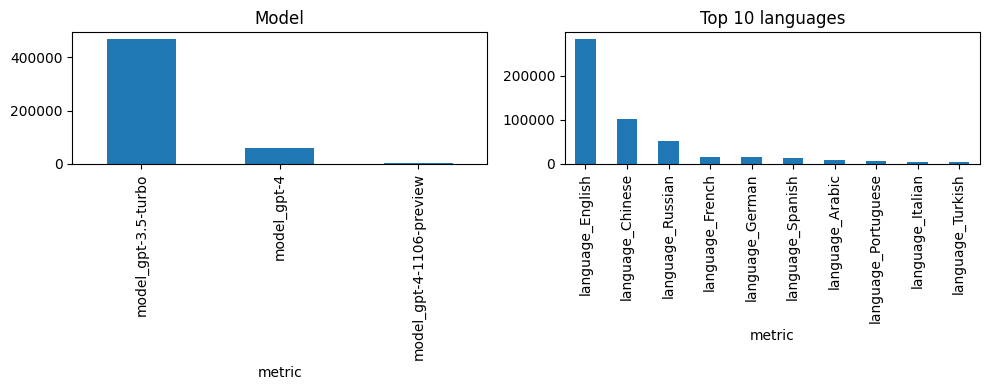

In [7]:
# Plots: model and top 10 languages
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
model_rows.set_index("metric")["value"].plot(kind="bar", ax=ax1, title="Model")
ax1.tick_params(axis="x", rotation=90)
lang_rows.head(10).set_index("metric")["value"].plot(kind="bar", ax=ax2, title="Top 10 languages")
ax2.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## Step 4: Conversation and message length

Per-conversation message counts and character lengths (user vs assistant).

In [8]:
path_step4 = Path(EDA_OUTPUT_DIR) / "step4_message_length.parquet"
step4_df = load_or_build(path_step4, LOAD_FROM_SAVED, build_step4_message_length, df)
# Format floats without trailing zeros
def _fmt(x):
    if pd.isna(x): return ""
    return str(int(x)) if x == int(x) else f"{x:.2f}".rstrip("0").rstrip(".")
display(step4_df.head(10).style.format({"user_mean_words": _fmt, "assistant_mean_words": _fmt}))
print("Summary (median/mean words per message):")
display(step4_df[["user_mean_words", "assistant_mean_words"]].describe().style.format(_fmt))

,conversation_idx,n_messages,total_words,user_mean_words,user_total_words,assistant_mean_words,assistant_total_words,n_user_msgs,n_assistant_msgs
0,0,2,736,52,52,684,684,1,1
1,1,2,35,3,3,32,32,1,1
2,2,2,620,30,30,590,590,1,1
3,3,2,607,454,454,153,153,1,1
4,4,6,769,91,273,165.33,496,3,3
5,5,2,643,32,32,611,611,1,1
6,6,2,601,454,454,147,147,1,1
7,7,2,746,56,56,690,690,1,1
8,8,2,630,454,454,176,176,1,1
9,9,2,229,153,153,76,76,1,1


Summary (median/mean words per message):


,user_mean_words,assistant_mean_words
count,529428,529428
mean,139.03,197.79
std,326.08,204.61
min,0,0
25%,6,36
50%,19,145.19
75%,100.5,303
max,22343,3296


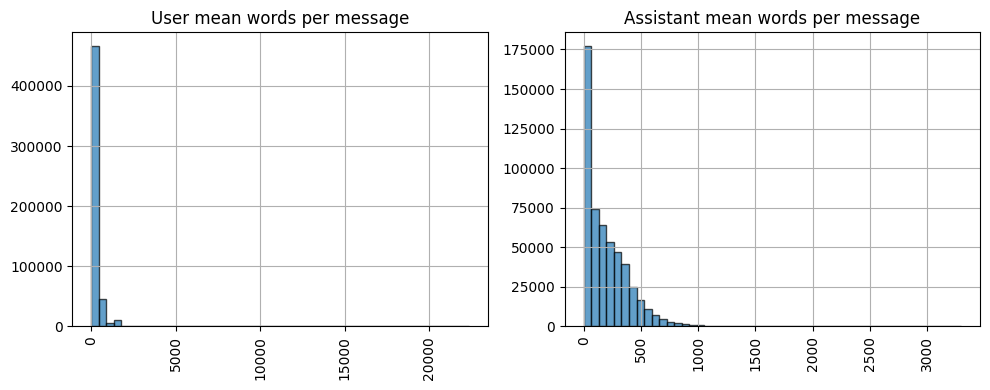

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
step4_df["user_mean_words"].hist(ax=ax1, bins=50, edgecolor="black", alpha=0.7)
ax1.set_title("User mean words per message")
ax1.tick_params(axis="x", rotation=90)
step4_df["assistant_mean_words"].hist(ax=ax2, bins=50, edgecolor="black", alpha=0.7)
ax2.set_title("Assistant mean words per message")
ax2.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## Step 5: Temporal distribution

Conversation count over time.

,date,count
0,2023-04-10,2034
1,2023-04-11,2212
2,2023-04-12,1961
3,2023-04-13,2069
4,2023-04-14,2077
5,2023-04-15,1636
6,2023-04-16,1925
7,2023-04-17,2504
8,2023-04-18,2496
9,2023-04-19,2495


Date range: 2023-04-10 to 2023-11-09 (213 days)
Total conversations: 529,428
Average conversations per day: 2,485.6


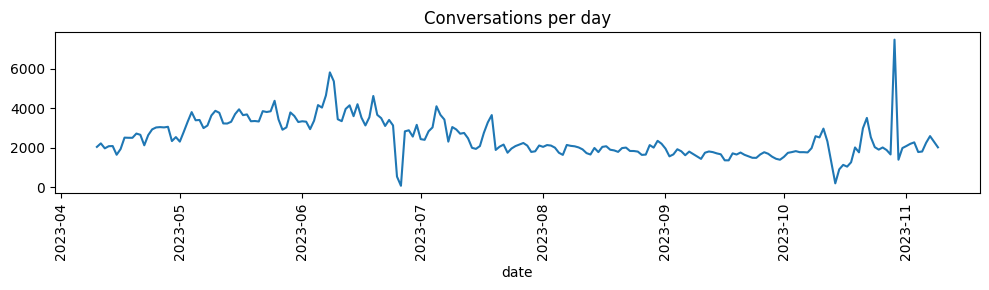

In [10]:
path_step5 = Path(EDA_OUTPUT_DIR) / "step5_temporal.parquet"
step5_df = load_or_build(path_step5, LOAD_FROM_SAVED, build_step5_temporal, df)
display(step5_df.head(10))

# Average conversations per day (over the date range present in the data)
total_conv = step5_df["count"].sum()
n_days = len(step5_df)
avg_conv_per_day = total_conv / n_days if n_days else 0
date_min, date_max = step5_df["date"].min(), step5_df["date"].max()
print(f"Date range: {date_min} to {date_max} ({n_days} days)")
print(f"Total conversations: {total_conv:,}")
print(f"Average conversations per day: {avg_conv_per_day:,.1f}")

ax = step5_df.set_index("date")["count"].plot(figsize=(10, 3), title="Conversations per day")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

### Comparison to ChatGPT total traffic (rough estimate)

Public estimates for ChatGPT during the WildChat collection period (Apr–Nov 2023): on the order of **10–100 million** queries or visits per day (e.g. ~10M queries/day early 2023, ~60M daily visits April 2023, ~100M daily visits May 2023; sources: Similarweb, TechCrunch). Visits and conversations are not identical; the range is indicative. Below we compute what fraction of that total this dataset represents.

In [11]:
# Rough ChatGPT daily volume (range from public estimates, Apr–Nov 2023)
CHATGPT_DAILY_LOW = 10_000_000   # ~10M queries/day (early 2023)
CHATGPT_DAILY_HIGH = 100_000_000 # ~100M visits/day (peak 2023)

pct_low = 100 * avg_conv_per_day / CHATGPT_DAILY_HIGH if CHATGPT_DAILY_HIGH else 0
pct_high = 100 * avg_conv_per_day / CHATGPT_DAILY_LOW if CHATGPT_DAILY_LOW else 0
print(f"Dataset average: {avg_conv_per_day:,.0f} conversations/day")
print(f"Rough ChatGPT total (public estimates): ~{CHATGPT_DAILY_LOW/1e6:.0f}M–{CHATGPT_DAILY_HIGH/1e6:.0f}M per day in 2023")
print(f"This dataset as share of that total: ~{pct_low:.3f}%–{pct_high:.3f}%")
print("(Interpretation: WildChat is a small sample of total ChatGPT traffic.)")

Dataset average: 2,486 conversations/day
Rough ChatGPT total (public estimates): ~10M–100M per day in 2023
This dataset as share of that total: ~0.002%–0.025%
(Interpretation: WildChat is a small sample of total ChatGPT traffic.)


## Step 6: Moderation and quality flags

Toxic / redacted counts; post-filter dataset should be mostly non-toxic.

In [12]:
path_step6 = Path(EDA_OUTPUT_DIR) / "step6_moderation.parquet"
step6_df = load_or_build(path_step6, LOAD_FROM_SAVED, build_step6_moderation, df)
display(step6_df)

,metric,value
0,toxic_true,0.0
1,toxic_false,529428.0
2,redacted_true,3215.0
3,redacted_false,526213.0
4,detoxify_toxicity_max_mean,0.0


## Step 7: Empty and short user inputs

Conversations with at least one empty or whitespace-only user message.

In [13]:
path_step7 = Path(EDA_OUTPUT_DIR) / "step7_empty_inputs.parquet"
step7_df = load_or_build(path_step7, LOAD_FROM_SAVED, build_step7_empty_inputs, df)
display(step7_df.head(10))

,metric,value
0,conversations_with_empty_user_input,0.0
1,pct_with_empty_user_input,0.0


## Step 8: Content sampling and keyword counts

Sample conversations by turn count; optional keyword counts.

In [14]:
path_step8 = Path(EDA_OUTPUT_DIR) / "step8_keyword_counts.parquet"
step8_df = load_or_build(path_step8, LOAD_FROM_SAVED, build_step8_keyword_counts, df)
display(step8_df)

,keyword,conversation_count
0,code,0
1,translate,0
2,write,0
3,python,0
4,explain,0


In [15]:
# Sample conversations: one single-turn, one 3-turn, one long
def show_convo(conv, max_len=200):
    if conv is None or len(conv) == 0:
        print("  (none)")
        return
    for i, m in enumerate(conv):
        c = (m.get("content") or "")[:max_len]
        if len((m.get("content") or "")) > max_len:
            c += "..."
        print(f"  [{i}] {m.get('role')}: {c}")
single = df[df["turn"] == 1].iloc[0]["conversation"]
three = df[df["turn"] == 3]
three = three.iloc[len(three) // 2]["conversation"] if len(three) else []
long_df = df[df["turn"] >= 10]
long_conv = long_df.iloc[0]["conversation"] if len(long_df) else []
print("Single-turn:"); show_convo(single)
print("\n3-turn (middle):"); show_convo(three)
print("\nLong (>=10 turns):"); show_convo(long_conv)

Single-turn:
  [0] user: Write a very long, elaborate, descriptive and detailed shooting script, including a background and dialogues, for a John Waters-inspired film scene that includes a character preparing omelettes. You a...
  [1] assistant: Title: "Divine Decadence: Omelette a la Waters"

EXT. MORNINGSIDE EDGE TRAILER PARK - DAY

The sun casts a warm glow over the eclectic collection of trailers that make up the Morningside Edge Trailer ...

3-turn (middle):
  [0] user: Fanfic: What if naruto was the reincarnation of Team Lilac (Sash Lilac, Carol Tea and Milla Basset) prat 1. Sash Lilac, Carol Tea and Milla Basset see like his life Naruto
  [1] assistant: was born in the hidden leaf village just like any other ninja. But little did anyone know, Naruto was actually the reincarnation of three intergalactic heroes - Sash Lilac, Carol Tea, and Milla Basset...
  [2] user: Fanfic: What if naruto was the reincarnation of Team Lilac (Sash Lilac, Carol Tea and Milla Basset) prat 2. Sash Li

## Step 9: Summary table

One-row summary: total conversations, turns, date range, top languages, model counts, % redacted, % empty user input, message lengths.

In [16]:
path_step9 = Path(EDA_OUTPUT_DIR) / "step9_summary.parquet"
step9_df = load_or_build(
    path_step9, LOAD_FROM_SAVED, build_step9_summary,
    df, step3_df, step4_df, step5_df, step6_df, step7_df,
)
display(step9_df.T)

,0
total_conversations,529428
total_turns,1242843
date_min,2023-04-10 00:01:08+00:00
date_max,2023-11-09 16:22:27+00:00
top3_languages,"English(284168), Chinese(101816), Russian(50584)"
model_counts,"gpt-3.5-turbo(470947), gpt-4(58024), gpt-4-110..."
pct_redacted,0.607259
pct_empty_user_input,0.0
median_user_msg_len,19.0
mean_user_msg_len,139.027913


## Takeaways

Use the summary and step tables above to decide filters for downstream use (e.g. instruction tuning): language, turn range, redaction, empty inputs. All mid-stage tables are under `eda_output/`; set `LOAD_FROM_SAVED = True` to skip recomputation.

## Export English-only (full dataset)

Filter to English conversations and save to chunked parquet files for easier loading. Uses the **full** dataset (not the sampled 5000). Run this once to create `data/english_chunks/`; then `insights_analysis.ipynb` can load from these files instead of the Hugging Face dataset.

In [17]:
# Full dataset: load, filter to English, write chunked parquet (not the 5000 sample)
from eda_utils import export_english_chunked_parquet, ensure_output_dir

ENGLISH_CHUNKS_DIR = "data/english_chunks"
CHUNK_SIZE = 50_000  # rows per parquet file

dataset_full = load_dataset("allenai/WildChat", split="train")
out_dir, n_written = export_english_chunked_parquet(
    dataset_full,
    output_dir=ENGLISH_CHUNKS_DIR,
    chunk_size=CHUNK_SIZE,
    language_col="language",
    language_value="English",
)
print(f"Wrote {n_written} English conversations to {out_dir} in chunked parquet files.")

Wrote 284168 English conversations to data/english_chunks in chunked parquet files.


#### There are 3 Potential topics to explore:
- Topic/Industry Specific Analysis - Choose one domain (e.g., health, finance, education) and analyze how users engage with it  

- Intent/Semantic Analysis - What themes appear most often? Are there emerging or underserved areas of interest?  

- Topic Modeling - understand the landscape of topics that are being searched and their relative frequencies 